<a href="https://colab.research.google.com/github/PeteBaum/EnergyDataAnalytics/blob/main/BESS_Optimization/SOLVED_WholesaleBessOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install Pyomo
!pip install -q pyomo

# 2. Install COIN-OR CBC Solver (Open Source Solver)
!apt-get install -y -qq coinor-cbc

print("Installation Complete. Ready to optimize.")

Selecting previously unselected package coinor-libcoinutils3v5:amd64.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../0-coinor-libcoinutils3v5_2.11.4+repack1-2_amd64.deb ...
Unpacking coinor-libcoinutils3v5:amd64 (2.11.4+repack1-2) ...
Selecting previously unselected package coinor-libosi1v5:amd64.
Preparing to unpack .../1-coinor-libosi1v5_0.108.6+repack1-2_amd64.deb ...
Unpacking coinor-libosi1v5:amd64 (0.108.6+repack1-2) ...
Selecting previously unselected package coinor-libclp1.
Preparing to unpack .../2-coinor-libclp1_1.17.5+repack1-1_amd64.deb ...
Unpacking coinor-libclp1 (1.17.5+repack1-1) ...
Selecting previously unselected package coinor-libcgl1:amd64.
Preparing to unpack .../3-coinor-libcgl1_0.60.3+repack1-3_amd64.deb ...
Unpacking coinor-libcgl1:amd64 (0.60.3+repack1-3) ...
Selecting previously unselected package coinor-libcbc3:amd64.
Preparing to unpack .../4-coinor-libcbc3_2.10.7+ds1-1_amd64.deb ...
Unpacking coinor-libcbc3:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

# --- A. Data Setup (Dummy Day-Ahead Prices) ---
# Creating a price curve: Low at night, high in the morning, low mid-day, high evening
prices = [
    30, 25, 20, 15, 10, 15, 40, 80,  # 00:00 - 07:00 (Night/Morning Peak)
    75, 60, 50, 40, 30, 20, 15, 20,  # 08:00 - 15:00 (Solar Dip)
    50, 90, 100, 95, 80, 60, 40, 35  # 16:00 - 23:00 (Evening Peak)
]
hours = range(24)

# --- B. Battery Parameters ---
P_MAX = 1.0    # MW (Max Power)
E_MAX = 4.0    # MWh (Max Energy Capacity) - 4 hour duration
EFF = 0.95     # Round trip efficiency (sqrt(0.9) approx)
SOC_START = 2.0 # Starting with 50% charge
MAX_CYCLES = 1.0 # Max Amount of cycles

# --- C. Initialize Model ---
model = pyo.ConcreteModel()

# Time Index
model.T = pyo.Set(initialize=hours)

# --- D. Define Variables ---

# 1. Power Variables (Continuous, Non-Negative)
model.P_ch = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_dis = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# 2. Binary Status Variable (1 = Charging, 0 = Discharging)
model.u = pyo.Var(model.T, domain=pyo.Binary)

# ---------------------------------------------------------
# ### EXERCISE 1 ###
# Task: Define the State of Charge (SOC) variable.
# It must be indexed by time (model.T) and be non-negative.
# ---------------------------------------------------------

# Solution:
model.soc = pyo.Var(model.T, domain=pyo.NonNegativeReals)

print("Model and Variables Initialized.")

Model and Variables Initialized.


In [3]:
# --- E. Objective Function ---
# Maximize Profit = (Revenue from Discharge) - (Cost of Charging)

def profit_obj(model):
    return sum(model.P_dis[t] * prices[t] - model.P_ch[t] * prices[t] for t in model.T)

model.objective = pyo.Objective(rule=profit_obj, sense=pyo.maximize)


# --- F. Constraints ---

# 1. Logical Constraint: Cannot Charge and Discharge at the same time
# If u[t] == 1, P_dis must be 0. If u[t] == 0, P_ch must be 0.
def logic_ch_rule(model, t):
    return model.P_ch[t] <= P_MAX * model.u[t]

def logic_dis_rule(model, t):
    return model.P_dis[t] <= P_MAX * (1 - model.u[t])

model.const_logic_ch = pyo.Constraint(model.T, rule=logic_ch_rule)
model.const_logic_dis = pyo.Constraint(model.T, rule=logic_dis_rule)

# ---------------------------------------------------------
# ### EXERCISE 2 ###
# Task: Defome the capacity rule
# Logic: SOC[t] < SOCmax
# ---------------------------------------------------------
def capacity_rule(model, t):
    return model.soc[t] <= E_MAX

model.const_capacity = pyo.Constraint(model.T, rule=capacity_rule)

# ---------------------------------------------------------
# ### EXERCISE 3 ###
# Task: Define the Energy Balance (SOC) Constraint.
# Logic: SOC[t] = SOC[t-1] + Charge - Discharge
# Don't forget to handle t=0 (use SOC_START)!
# ---------------------------------------------------------
def energy_balance_rule(model, t):
    # Energy in -> Charge * Efficiency
    # Energy out -> Discharge / Efficiency

    if t == 0:
        return model.soc[t] == SOC_START + (model.P_ch[t] * EFF) - (model.P_dis[t] / EFF)
    else:
        return model.soc[t] == model.soc[t-1] + (model.P_ch[t] * EFF) - (model.P_dis[t] / EFF)

# Solution application:
model.const_energy_balance = pyo.Constraint(model.T, rule=energy_balance_rule)

# ---------------------------------------------------------
# ### EXERCISE 4 ###
# Task: Define the Cycles/Max Throughput Constraint.
# ---------------------------------------------------------

print("Constraints and Objective defined.")

Constraints and Objective defined.


Solver Status: ok
Termination Condition: optimal


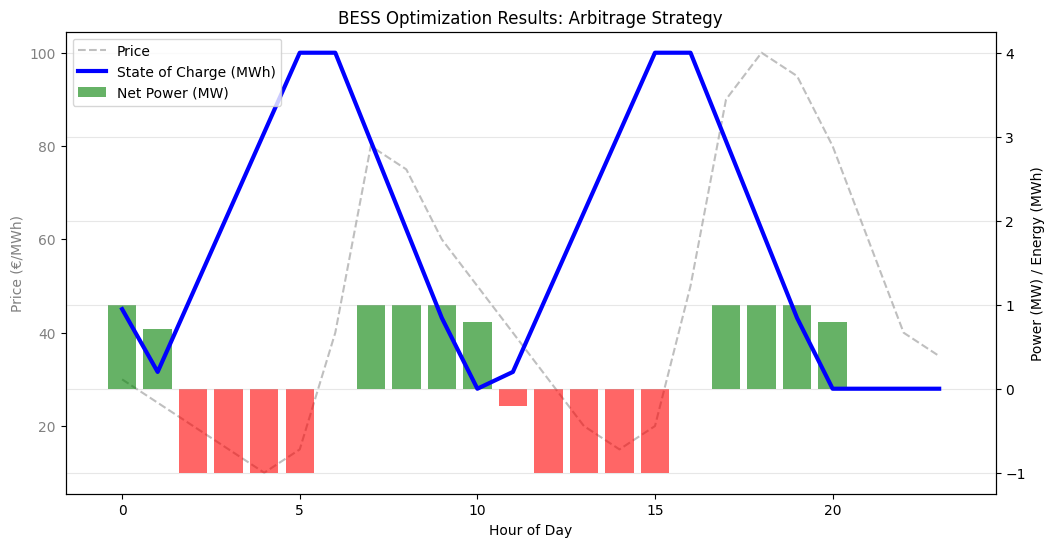

In [4]:
# --- G. Solve the Model ---
# We use the 'cbc' solver we installed in Cell 1
solver = pyo.SolverFactory('cbc')
results = solver.solve(model)

# Check if optimal solution was found
print(f"Solver Status: {results.solver.status}")
print(f"Termination Condition: {results.solver.termination_condition}")


# --- H. Extract Results for Plotting ---
import numpy as np

# Extract values from Pyomo variables into Python lists
p_ch_vals = [pyo.value(model.P_ch[t]) for t in hours]
p_dis_vals = [pyo.value(model.P_dis[t]) for t in hours]
if hasattr(model, "soc"):
  soc_vals = [pyo.value(model.soc[t]) for t in hours]
else:
  soc_vals = [0]*24
net_power = np.array(p_dis_vals) - np.array(p_ch_vals) # Positive = Selling


# --- I. Visualization ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Prices (Background Area)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Price (€/MWh)', color='gray')
ax1.plot(hours, prices, color='gray', linestyle='--', alpha=0.5, label='Price')
ax1.tick_params(axis='y', labelcolor='gray')

# Create a second y-axis for Power and SOC
ax2 = ax1.twinx()
ax2.set_ylabel('Power (MW) / Energy (MWh)', color='black')

# Plot SOC (Line)
ax2.plot(hours, soc_vals, color='blue', linewidth=3, label='State of Charge (MWh)')

# Plot Dispatch (Bars)
# Green bars for Discharge (Selling), Red bars for Charge (Buying)
colors = ['green' if p > 0 else 'red' for p in net_power]
ax2.bar(hours, net_power, color=colors, alpha=0.6, label='Net Power (MW)')

# Formatting
plt.title('BESS Optimization Results: Arbitrage Strategy')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()